In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for publication-ready graphs
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

In [18]:
# Load the data
csv_file = "bfs_results.csv"
try:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded {len(df)} rows from {csv_file}")
except FileNotFoundError:
    print(f"Error: {csv_file} not found. Please ensure it is in the same directory.")

# Filter out failed runs (if any) and mismatches
df_clean = df[df["Status"] == "OK"].copy()

print(f"Analyzing {len(df_clean)} successfully solved boards.")

# Display basic summary statistics
df_clean[["Moves", "Visited_States", "Runtime_sec", "Peak_Memory_MB"]].describe().to_latex()

Successfully loaded 476118 rows from bfs_results.csv
Analyzing 476118 successfully solved boards.


'\\begin{tabular}{lrrrr}\n\\toprule\n & Moves & Visited_States & Runtime_sec & Peak_Memory_MB \\\\\n\\midrule\ncount & 476118.000000 & 476118.000000 & 476118.000000 & 476118.000000 \\\\\nmean & 12.266146 & 2056.588680 & 0.030598 & 0.073379 \\\\\nstd & 4.188763 & 3356.010441 & 0.057225 & 0.341666 \\\\\nmin & 1.000000 & 1.000000 & 0.000013 & 0.000000 \\\\\n25% & 10.000000 & 387.000000 & 0.004252 & 0.000000 \\\\\n50% & 11.000000 & 965.000000 & 0.012169 & 0.000000 \\\\\n75% & 14.000000 & 2328.000000 & 0.032914 & 0.003906 \\\\\nmax & 51.000000 & 139992.000000 & 2.766274 & 21.261719 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [7]:
df_clean = df_clean[df_clean['Peak_Memory_MB'] > 0]

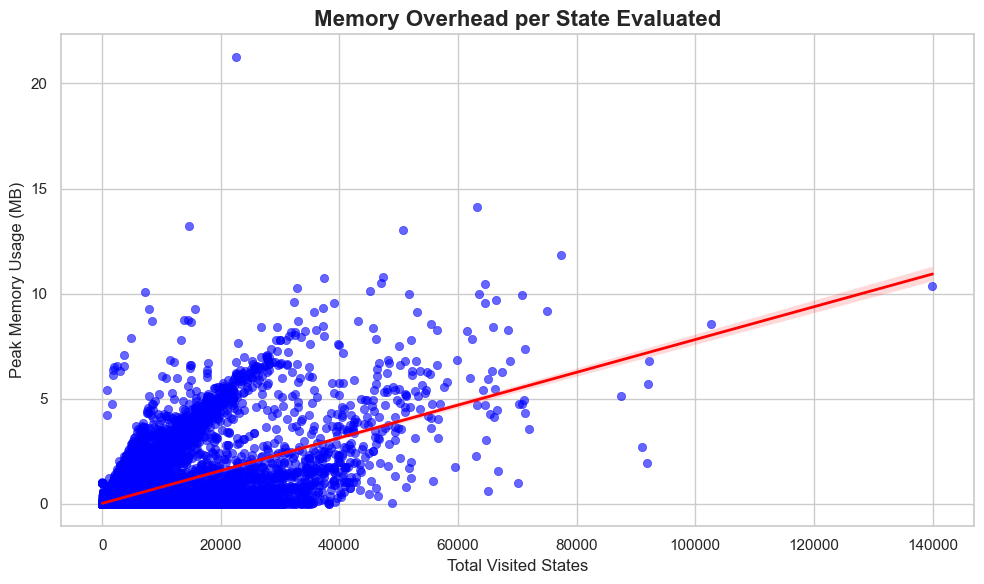

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x="Visited_States", 
    y="Peak_Memory_MB", 
    alpha=0.6, 
    edgecolor=None,
    color="blue"
)

# Add a trendline to show the strict linear relationship
sns.regplot(
    data=df_clean, 
    x="Visited_States", 
    y="Peak_Memory_MB", 
    scatter=False, 
    color="red", 
    line_kws={"linewidth": 2}
)

plt.title("Memory Overhead per State Evaluated", fontsize=16, fontweight='bold')
plt.xlabel("Total Visited States", fontsize=12)
plt.ylabel("Peak Memory Usage (MB)", fontsize=12)
plt.tight_layout()
plt.show()

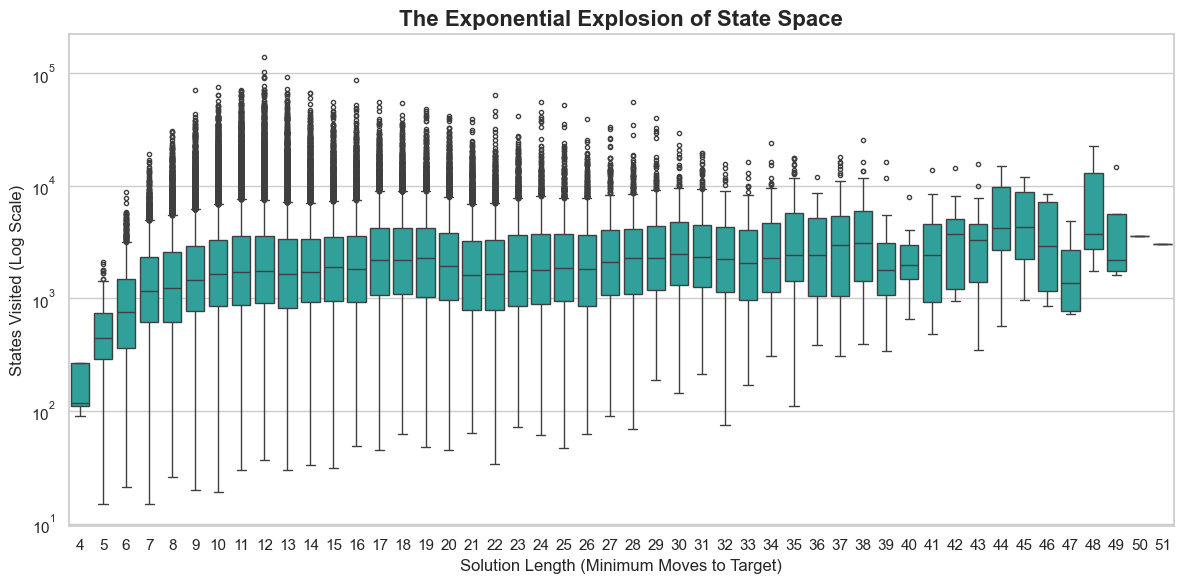

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot shows the distribution of states for each specific solution length
sns.boxplot(
    data=df_clean, 
    x="Moves", 
    y="Visited_States", 
    color="lightseagreen",
    fliersize=3
)

plt.yscale("log") # Log scale is crucial here for exponential growth
plt.title("State Space vs solution length on log scale", fontsize=16, fontweight='bold')
plt.xlabel("Solution Length (Minimum Moves to Target)", fontsize=12)
plt.ylabel("States Visited (Log Scale)", fontsize=12)
plt.tight_layout()
plt.show()

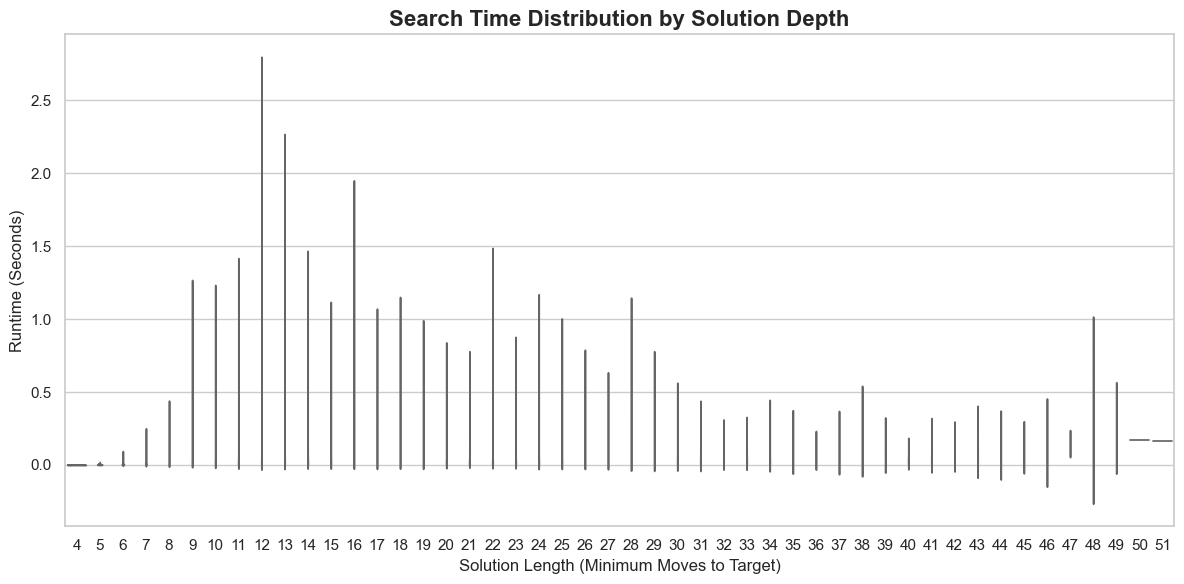

In [10]:
plt.figure(figsize=(12, 6))

# We use a violin plot to show where the majority of runtimes cluster
sns.violinplot(
    data=df_clean, 
    x="Moves", 
    y="Runtime_sec", 
    inner="quartile",
    color="coral"
)

plt.title("Search Time Distribution by Solution Depth", fontsize=16, fontweight='bold')
plt.xlabel("Solution Length (Minimum Moves to Target)", fontsize=12)
plt.ylabel("Runtime (Seconds)", fontsize=12)
plt.tight_layout()
plt.show()

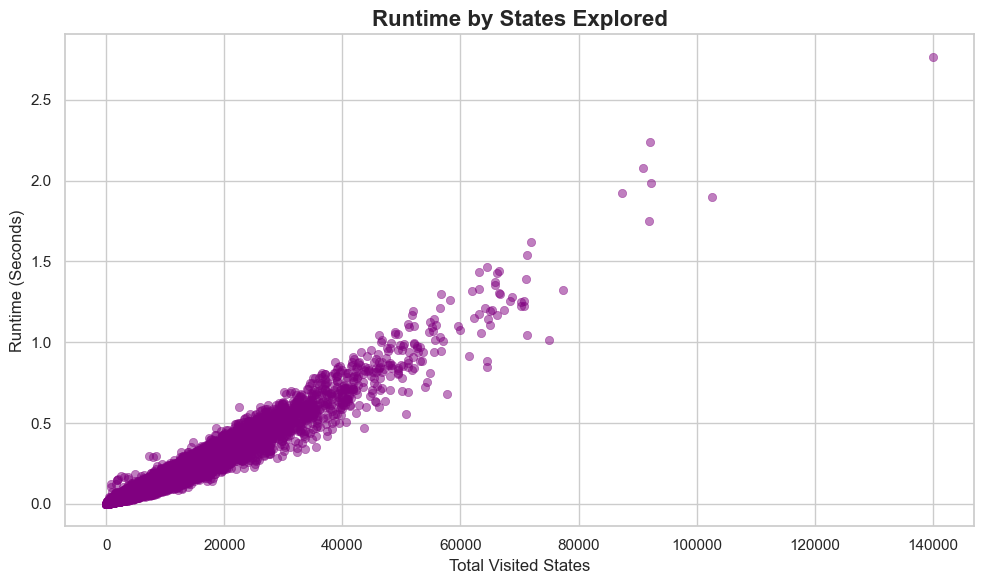

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean, 
    x="Visited_States", 
    y="Runtime_sec", 
    alpha=0.5, 
    edgecolor=None,
    color="purple"
)

plt.title("Runtime by States Explored", fontsize=16, fontweight='bold')
plt.xlabel("Total Visited States", fontsize=12)
plt.ylabel("Runtime (Seconds)", fontsize=12)
plt.tight_layout()
plt.show()